In [1]:

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import (
    Sinusoid, SinSignal, CosSignal,
    SquareSignal, TriangleSignal, ParabolicSignal,
    normalize, unbias, decorate
)

--2026-05-12 10:11:51--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-12 10:11:52--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.006s  

2026-05-12 10:11:52 (8.04 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



## Упражнение 2.2. Пилообразный сигнал

Пилообразный сигнал линейно возрастает от −1 до 1, затем резко падает до −1 и повторяется.

Нужно:
1. написать класс `SawtoothSignal`;
2. вычислить спектр;
3. сравнить гармоническую структуру с треугольным и прямоугольным сигналами.

In [2]:
class SawtoothSignal(Sinusoid):
    """Пилообразный сигнал: линейный рост от -amp до +amp и резкий спад."""

    def evaluate(self, ts):
        """Вычисляет значения сигнала в моменты времени ts."""
        cycles = self.freq * ts + self.offset / (2 * np.pi)
        frac, _ = np.modf(cycles)          # дробная часть цикла: [0, 1)
        ys = normalize(unbias(frac), self.amp)  # переводим к диапазону [-amp, amp]
        return ys

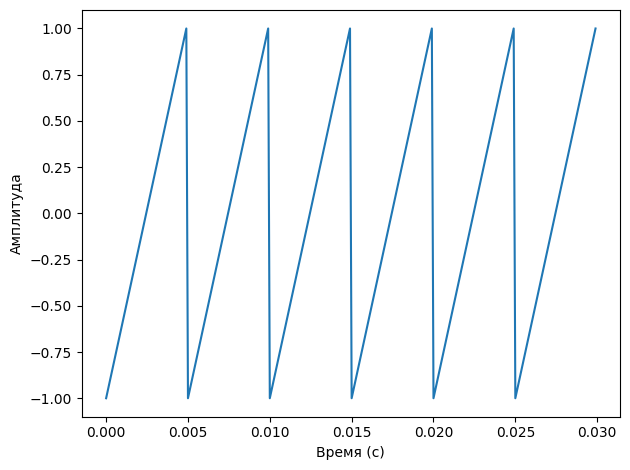

In [3]:
# Посмотрим на форму сигнала
signal = SawtoothSignal(freq=200)
wave = signal.make_wave(duration=0.03, framerate=10000)
wave.plot()
decorate(xlabel='Время (с)', ylabel='Амплитуда')

In [4]:
# Послушаем пилообразный сигнал
sawtooth = SawtoothSignal(freq=440).make_wave(duration=0.5, framerate=40000)
sawtooth.make_audio()

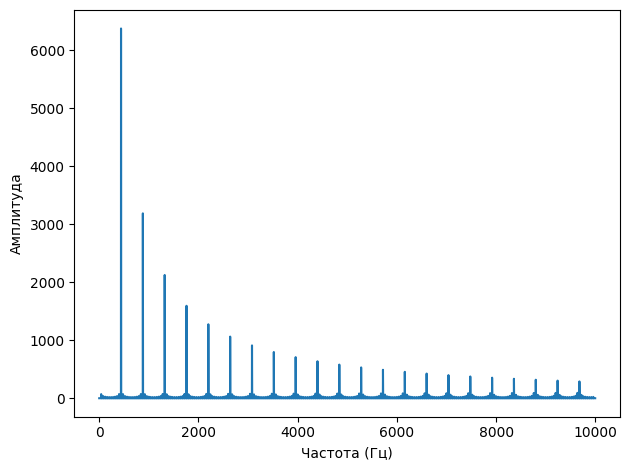

In [5]:
# Спектр пилообразного сигнала
spectrum = sawtooth.make_spectrum()
spectrum.plot(high=10000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

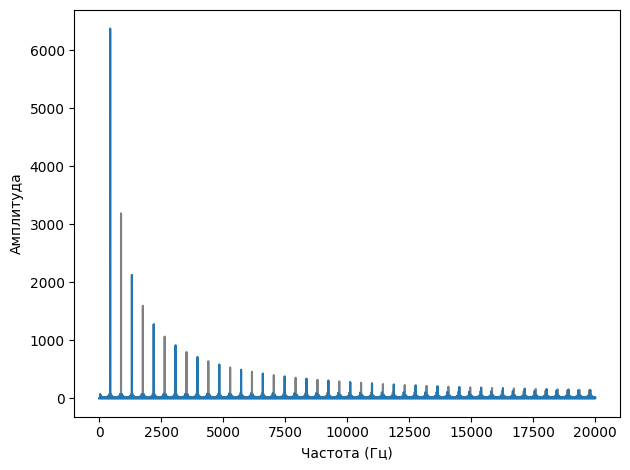

In [6]:
# Сравнение с прямоугольным сигналом
square = SquareSignal(freq=440, amp=0.5).make_wave(duration=0.5, framerate=40000)

sawtooth.make_spectrum().plot(color='gray')
square.make_spectrum().plot()
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

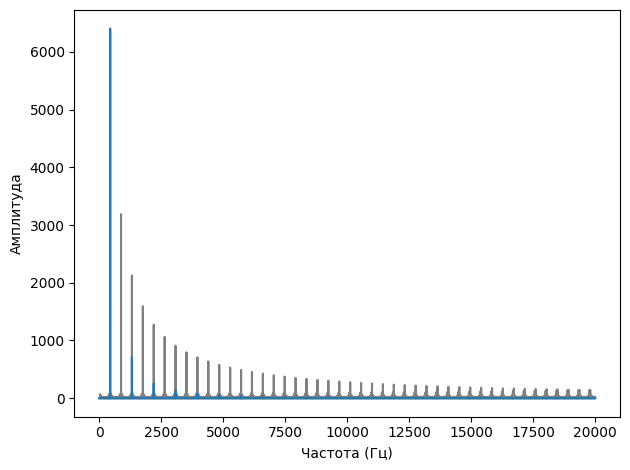

In [7]:
# Сравнение с треугольным сигналом
triangle = TriangleSignal(freq=440, amp=0.79).make_wave(duration=0.5, framerate=40000)

sawtooth.make_spectrum().plot(color='gray')
triangle.make_spectrum().plot()
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

**Вывод.** Пилообразный сигнал содержит и чётные, и нечётные гармоники. Амплитуды его гармоник убывают примерно как `1/f`, то есть похоже на прямоугольный сигнал. У треугольного сигнала гармоники убывают быстрее — примерно как `1/f²`, и присутствуют только нечётные гармоники.

## Упражнение 2.3. Прямоугольный сигнал 1100 Гц и алиасинг

Нужно создать прямоугольный сигнал частотой 1100 Гц при частоте дискретизации 10000 кадров/с, построить спектр и проверить, что многие гармоники «завернуты» из-за биений / алиасинга.

In [8]:
framerate = 10000
freq = 1100

square_1100 = SquareSignal(freq=freq).make_wave(duration=0.5, framerate=framerate)
square_1100.make_audio()

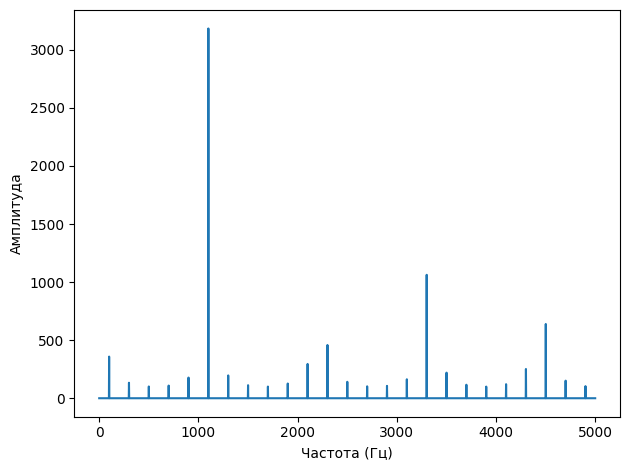

In [9]:
spectrum = square_1100.make_spectrum()
spectrum.plot(high=framerate/2)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

In [10]:
# Покажем, куда попадают первые нечётные гармоники
nyquist = framerate / 2
harmonics = np.array([1, 3, 5, 7, 9, 11, 13]) * freq

# Частота после «заворота» в диапазон [0, framerate/2]
aliases = np.abs((harmonics + framerate/2) % framerate - framerate/2)

for h, a in zip(harmonics, aliases):
    print(f'{h:5.0f} Гц -> {a:5.0f} Гц')

 1100 Гц ->  1100 Гц
 3300 Гц ->  3300 Гц
 5500 Гц ->  4500 Гц
 7700 Гц ->  2300 Гц
 9900 Гц ->   100 Гц
12100 Гц ->  2100 Гц
14300 Гц ->  4300 Гц


**Вывод.** Для частоты дискретизации 10000 Гц частота Найквиста равна 5000 Гц. Поэтому гармоники выше 5000 Гц заворачиваются обратно в слышимый диапазон. Например, 5500 Гц превращается в 4500 Гц, 7700 Гц — в 2300 Гц, 9900 Гц — в 100 Гц. При прослушивании слышен не «чистый» прямоугольный сигнал 1100 Гц, а сигнал с заметными алиасными компонентами.

## Упражнение 2.4. Нулевая частота в спектре

`Spectrum.hs[0]` соответствует компоненте с частотой 0 Гц. Это постоянная составляющая сигнала, или DC offset.

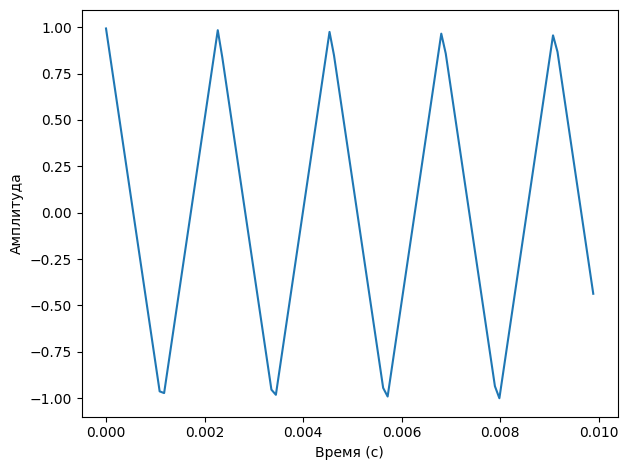

In [11]:
# Треугольный сигнал 440 Гц длительностью 0.01 с
triangle = TriangleSignal(freq=440).make_wave(duration=0.01, framerate=11025)
triangle.plot()
decorate(xlabel='Время (с)', ylabel='Амплитуда')

In [12]:
spectrum = triangle.make_spectrum()
print('spectrum.fs[:5] =', spectrum.fs[:5])
print('spectrum.hs[0]  =', spectrum.hs[0])
print('Амплитуда hs[0] =', abs(spectrum.hs[0]))
print('Фаза hs[0]      =', np.angle(spectrum.hs[0]))

spectrum.fs[:5] = [  0.         100.22727273 200.45454545 300.68181818 400.90909091]
spectrum.hs[0]  = (1.0436096431476471e-14+0j)
Амплитуда hs[0] = 1.0436096431476471e-14
Фаза hs[0]      = 0.0


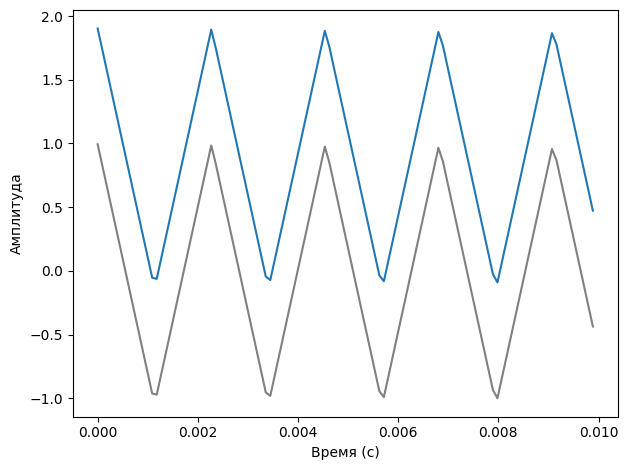

In [13]:
# Изменим нулевую частотную компоненту
spectrum.hs[0] = 100

triangle.plot(color='gray')
modified = spectrum.make_wave()
modified.plot()
decorate(xlabel='Время (с)', ylabel='Амплитуда')

**Вывод.** Компонента 0 Гц — это постоянное смещение сигнала вверх или вниз. Если увеличить `spectrum.hs[0]`, форма волны почти не меняется, но вся волна сдвигается по вертикали.

## Упражнение 2.5. Фильтр: деление `hs` на частоты `fs`

Нужно написать функцию, которая изменяет спектр: делит каждый элемент `hs` на соответствующую частоту `fs`. Деление на ноль запрещено, поэтому `hs[0]` нужно задать равным 0.

In [14]:
def filter_spectrum(spectrum):
    """Делит комплексные амплитуды спектра на соответствующие частоты.

    Нулевая частота обнуляется, чтобы избежать деления на ноль.
    Функция изменяет Spectrum на месте.
    """
    spectrum.hs[1:] /= spectrum.fs[1:]
    spectrum.hs[0] = 0

In [15]:
# Проверим на треугольном сигнале
wave = TriangleSignal(freq=440).make_wave(duration=0.5, framerate=20000)
wave.make_audio()

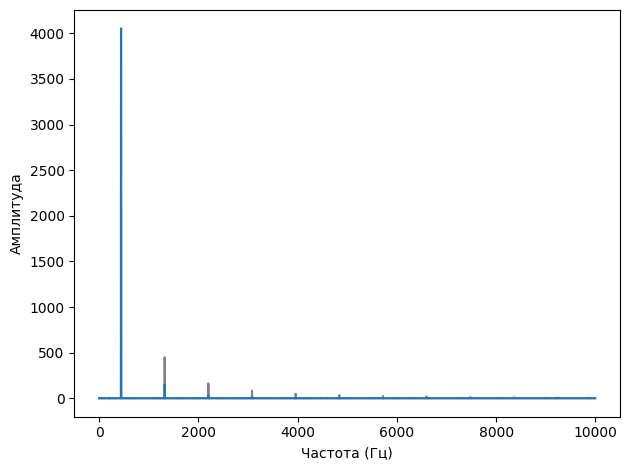

In [16]:
spectrum = wave.make_spectrum()

# Исходный спектр
spectrum.plot(high=10000, color='gray')

# Изменённый спектр; умножим на 440, чтобы графики было удобно сравнивать
filter_spectrum(spectrum)
spectrum.scale(440)
spectrum.plot(high=10000)

decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

In [17]:
filtered = spectrum.make_wave()
filtered.make_audio()

**Вывод.** Деление амплитуд на частоту дополнительно ослабляет высокие частоты, поэтому такая операция работает как фильтр нижних частот. После обработки треугольный сигнал звучит ближе к синусоидальному, потому что высшие гармоники становятся намного слабее.

## Упражнение 2.6. Сигнал с чётными и нечётными гармониками, убывающими как `1/f²`

Нужно найти сигнал, у которого:
- есть чётные и нечётные гармоники;
- амплитуды гармоник убывают пропорционально `1/f²`.

Есть два подхода: изменить спектр пилообразного сигнала или собрать сигнал из синусоид/косинусоид вручную.

### Способ 1: взять пилообразный сигнал и применить фильтр из упражнения 2.5

In [18]:
freq = 500
wave = SawtoothSignal(freq=freq).make_wave(duration=0.5, framerate=20000)
wave.make_audio()

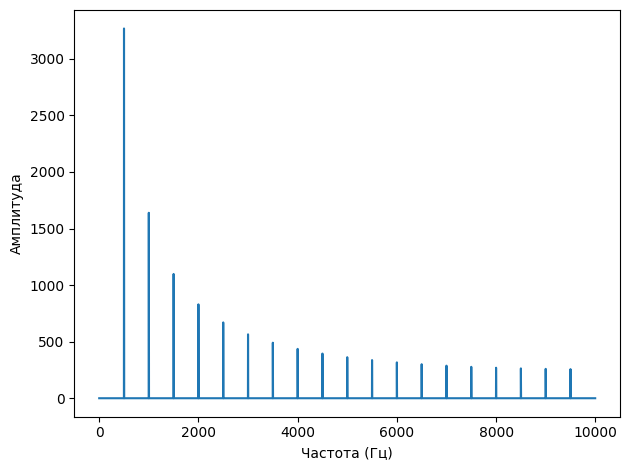

In [19]:
spectrum = wave.make_spectrum()
spectrum.plot(high=10000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

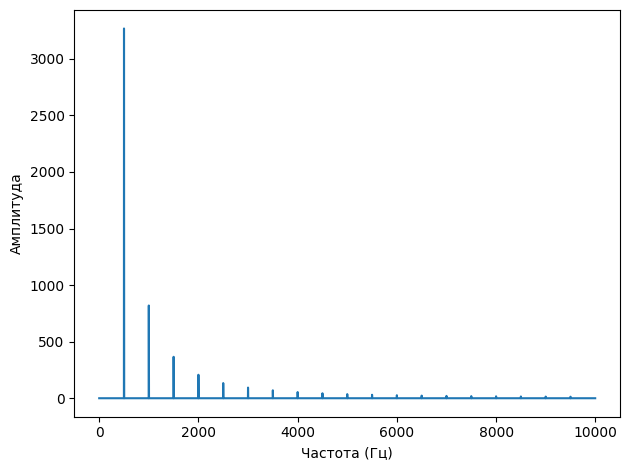

In [20]:
# Применим фильтр: спад 1/f превратится примерно в 1/f²
filter_spectrum(spectrum)
spectrum.scale(freq)
spectrum.plot(high=10000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

In [21]:
filtered_wave = spectrum.make_wave()
filtered_wave.make_audio()

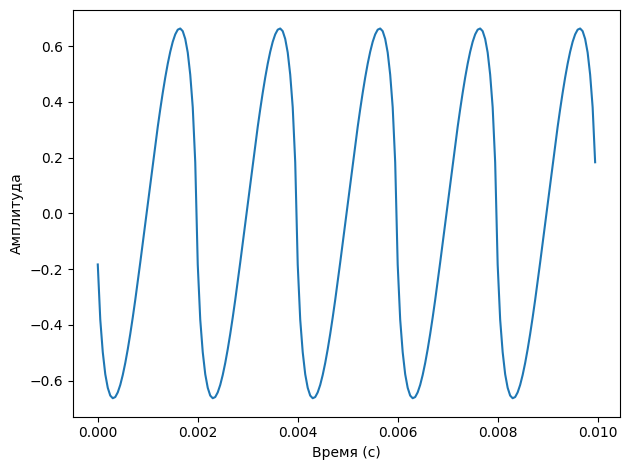

In [22]:
filtered_wave.segment(duration=0.01).plot()
decorate(xlabel='Время (с)', ylabel='Амплитуда')

### Способ 2: собрать сигнал из косинусоид с амплитудами `1/f²`

In [23]:
freqs = np.arange(500, 9500, 500)
amps = 1 / freqs**2

signal = sum(CosSignal(freq=f, amp=a) for f, a in zip(freqs, amps))
manual_wave = signal.make_wave(duration=0.5, framerate=20000)
manual_wave.make_audio()

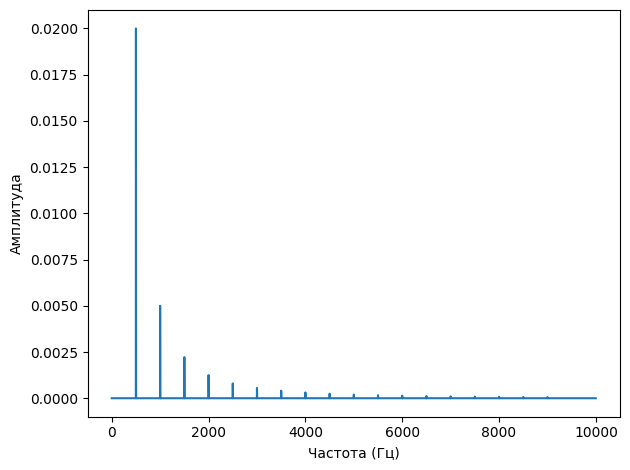

In [24]:
manual_wave.make_spectrum().plot(high=10000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

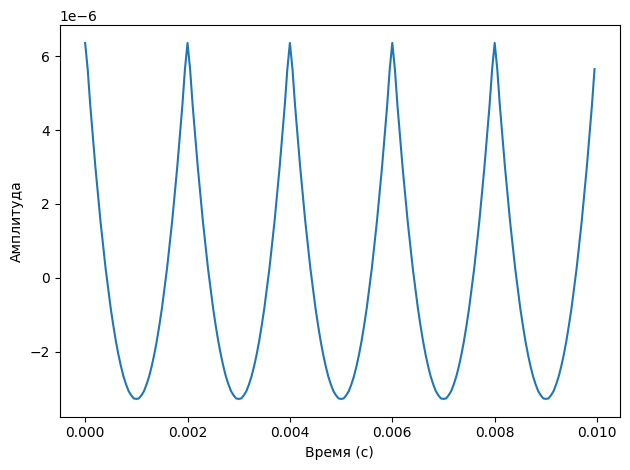

In [25]:
manual_wave.segment(duration=0.01).plot()
decorate(xlabel='Время (с)', ylabel='Амплитуда')

### Вариант из `thinkdsp`: `ParabolicSignal`

In [26]:
parabolic = ParabolicSignal(freq=500).make_wave(duration=0.5, framerate=20000)
parabolic.make_audio()

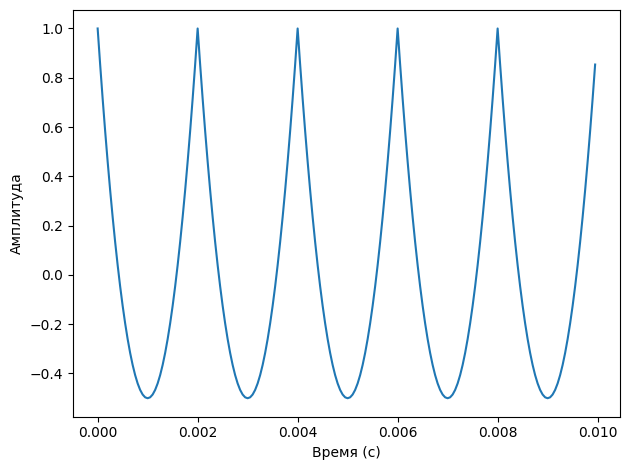

In [27]:
parabolic.segment(duration=0.01).plot()
decorate(xlabel='Время (с)', ylabel='Амплитуда')

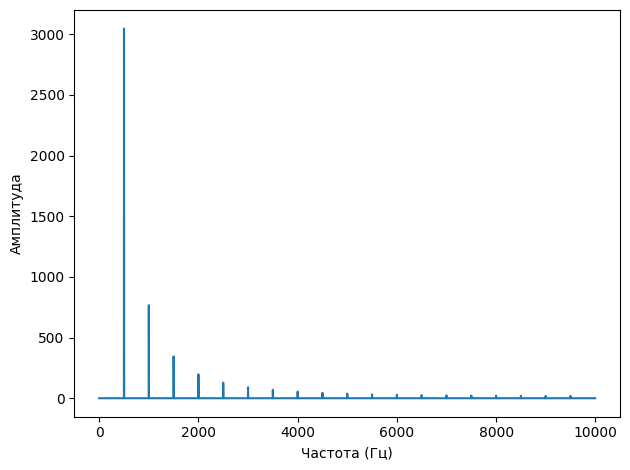

In [28]:
parabolic.make_spectrum().plot(high=10000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

**Вывод.** Подходящий пример — параболический сигнал. Он содержит чётные и нечётные гармоники, а амплитуды гармоник убывают примерно как `1/f²`. Его можно получить либо напрямую через `ParabolicSignal`, либо преобразованием спектра пилообразного сигнала.